In [1]:
# Import required system
import sys
sys.path.append('/Users/hoto7260/LIET/LIET/liet')

# general
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
try:
    np.distutils.__config__.blas_opt_info = np.distutils.__config__.blas_ilp64_opt_info
except Exception:
    pass
import pandas as pd

# my modules
from liet_res_class import FitParse
import rnap_lib_data_proc  as dp
import rnap_lib_data_sim as ds
from rnap_lib_fitting_results import results_loader, pdf_generator
import rnap_lib_plotting as rp

# setting plotting paramaters
from pylab import rcParams
rcParams['figure.figsize'] = 20, 6
rcParams['font.size'] = 15
#plt.rcParams.update({'font.size': 22})

In [2]:
# for each gene, get the proper locations
def get_LIET_end_results(LIET_df, endtype = "0.9_perc"):
    """
    Parameters
    ----------
    LIET_df: the LIET df output by FitParse in plotting_functions.py
    end_type: str
        - either EMG, Full, or another string (string must be a column in the dataframe)
        IN ALL CASES assumes the positive strand is the sense strand
    This function adds additional BID specific related elements to the dataframe: calculates the end positions for both strands.
    in: pandas Dataframe from the FitParse dataframe class with the sL, tI, and start information
    out: pandas DataFrame with the following ADDITIONAL columns (one row per bidirectional):
        * rel_pos_end = sL_mean + tI_mean
        * rel_pos_end_interval = (sL_mean - sL_stdev)+(tI_mean - tI_stdev),(sL_mean + sL_stdev)+(tI_mean + tI_stdev)
        * abs_pos_end = start + sL_mean + tI_mean
        * abs_pos_end_interval = start+[(sL_mean - sL_stdev)+(tI_mean - tI_stdev)],start+[(sL_mean + sL_stdev)+(tI_mean + tI_stdev)]
        * rel_neg_end = sL_a_mean + tI_a_mean
        * rel_neg_end_interval = (sL_a_mean - sL_a_stdev)+(tI_a_mean - tI_a_stdev),(sL_a_mean + sL_a_stdev)+(tI_a_mean + tI_a_stdev)
        * abs_neg_end = mu - sL_a_mean - tI_a_mean
        * abs_neg_end_interval = start+[(sL_a_mean - sL_a_stdev)+(tI_a_mean - tI_a_stdev)],start+[(sL_a_mean + sL_a_stdev)+(tI_a_mean + tI_a_stdev)]
    """
    # if mT then use that
    if endtype == "mT":
        # Positive
        LIET_df = LIET_df.assign(rel_pos_end = LIET_df["mT_mean"].astype(int)) 
        LIET_df = LIET_df.assign(abs_pos_end = LIET_df["start"]+LIET_df["mT_mean"].astype(int))
        LIET_df = LIET_df.assign(rel_neg_end = LIET_df["mT_a_mean"].astype(int)) 
        LIET_df = LIET_df.assign(abs_neg_end = LIET_df["start"]-LIET_df["mT_a_mean"].astype(int))
    else:
        # SENSE STRAND
        pos_end = "_".join([endtype, "pos"])
        LIET_df = LIET_df.assign(rel_pos_end = LIET_df[pos_end]) 
        LIET_df = LIET_df.assign(abs_pos_end = LIET_df["start"]+LIET_df[pos_end])
        # negative strand in my case
        neg_end = "_".join([endtype, "neg"])
        LIET_df = LIET_df.assign(rel_neg_end = LIET_df[neg_end]) 
        LIET_df = LIET_df.assign(abs_neg_end = LIET_df["start"]-LIET_df[neg_end])
    return LIET_df


def get_LIET_end_bed(LIET_df, end_type, antisense=True):
    """
    This function transforms the FitParse dataframe of bidirectionals into a bed file where the start position
    refers to the 3' most end of the - transcript and end to the 3' most end of the + transcript 
    (midpoint is NOT mu). Mu is saved as a separate column. The df also contains additional
    information that might be helpful for downstream analysis or evaluating the trustworthiness of the results.
    in: pandas Dataframe from the FitParse dataframe class that has undergone the get_LIET_end_results function.
    out: pandas DataFrame with the following columns (one row per bidirectional):
        * chr
        * start = most upstream (3' end of - strand)
        * end = most downstream (3' end of + strand)
        * name = name with |- or |+ according to strand
        * wLI_mean = w_LI_mean,w_aLI_mean
        * coverage = pos_cov,neg_cov
        * LI_coverage = coverage attributable to NOT background
        * rel_end_stdev = rel_pos_end_stdev,rel_neg_end_stdev
        * mu
        * elbo_lrange
    """
    if end_type == "EMG":
        LI_pos_cov = LIET_df["pos_cov"]*LIET_df["w_LI_mean"]
        rel_pos_end_stdev = LIET_df["sL_stdev"]+LIET_df["tI_stdev"]
        if antisense:
            LI_neg_cov = LIET_df["neg_cov"]*LIET_df["w_aLI_mean"]
            rel_neg_end_stdev = LIET_df["sL_a_stdev"]+LIET_df["tI_a_stdev"]
        else:
            LI_neg_cov = ["NA"]*len(LIET_df.chrom)
            rel_neg_end_stdev = ["NA"]*len(LIET_df.chrom)
        bed = pd.DataFrame({"chr": LIET_df.chrom, 
                               "start": LIET_df.start+LIET_df.mL_mean.astype(int), "end": LIET_df.abs_pos_end.astype(int), 
                              "name": LIET_df["gene"] , 
                              "wLI_mean": LIET_df["w_LI_mean"].astype(str)+","+LIET_df["w_aLI_mean"].astype(str),
                            "coverage": LIET_df["pos_cov"].astype(str)+","+LIET_df["neg_cov"].astype(str), 
                            "LI_coverage": LI_pos_cov.astype(int).astype(str)+","+LI_neg_cov.astype(int).astype(str),
                               "rel_end_stdev": rel_pos_end_stdev.round(1).astype(str)+","+rel_neg_end_stdev.round(1).astype(str), 
                           "mu":LIET_df.start, "elbow_lrange": LIET_df.elbo_lrange})
    else:
        if antisense:
            print("Not available rn")
        else:
            if end_type == "Full":
                rel_end_stdev=LIET_df["mT_stdev"].round(1).astype(str)
            else:
                rel_end_stdev= ["NA"]*len(LIET_df.chrom)
            non_wB_mean = 1 - LIET_df["w_B_mean"]
            LIE_pos_cov = LIET_df["pos_cov"]*non_wB_mean
            bed = pd.DataFrame({"chr": LIET_df.chrom, 
                                   "start": LIET_df.start+LIET_df.mL_mean.astype(int), "end": LIET_df.abs_pos_end.astype(int), 
                                  "name":  LIET_df["gene"]+"|+" , 
                                "LIET_coverage": LIE_pos_cov.astype(int),
                                "strand": ["+"]*LIET_df.shape[0],
                                "coverage": LIET_df["pos_cov"].astype(str), 
                                  "wLIET_mean": non_wB_mean.round(3),
                                "filler": ["."]*LIET_df.shape[0],
                                   "rel_end_stdev": rel_end_stdev, 
                               "mu":LIET_df.start, "elbow_lrange": LIET_df.elbo_lrange})
        
    return bed

def get_LIET_end_sep_bed(LIET_df, ET_sense=True, antisense=True, ET_antisense=False):
    """
    This function transforms the FitParse dataframe of bidirectionals into a bed file where the start position
    refers to the 3' most end of the - transcript and end to the 3' most end of the + transcript 
    (midpoint is NOT mu). Mu is saved as a separate column. The df also contains additional
    information that might be helpful for downstream analysis or evaluating the trustworthiness of the results.
    in: pandas Dataframe from the FitParse dataframe class that has undergone the get_LIET_end_results function.
    out: pandas DataFrame with the following columns (two rows per bidirectional):
        * chr
        * start = most upstream (3' end of - strand & 5' end of + strand)
        * end = most downstream (3' end of + strand & 5' end of - strand)
        * name = name with |- or |+ according to strand
        * wLI_mean = w_LI_mean or w_aLI_mean
        * coverage = pos_cov or neg_cov
        * LI_coverage = coverage attributable to NOT background
        * rel_end_stdev = rel_pos_end_stdev or rel_neg_end_stdev
        * mu
        * elbo_lrange (same for both strands)
    """
    # get the postive strand bed
    if ET_sense:
        w_LIET = 1-LIET_df["w_B_mean"]
        LIET_pos_cov = LIET_df["pos_cov"]*w_LIET
        pos_bed = pd.DataFrame({"chr": LIET_df.chrom, 
                               "start": LIET_df.start+LIET_df.mL_mean.astype(int), "end": LIET_df.abs_pos_end.astype(int), 
                              "name": LIET_df["gene"]+"|+" , 
                                "LIET_coverage": LIET_pos_cov.astype(int),
                                "strand": ["+"]*LIET_df.shape[0],
                            "coverage": LIET_df["pos_cov"], 
                                "wLIET_mean": w_LIET.round(3),
                                "filler": ["."]*LIET_df.shape[0],
                           "mu":LIET_df.start, "elbow_lrange": LIET_df.elbo_lrange})
    else:
        LI_pos_cov = LIET_df["pos_cov"]*LIET_df["w_LI_mean"]
        pos_bed = pd.DataFrame({"chr": LIET_df.chrom, 
                               "start": LIET_df.start+LIET_df.mL_mean.astype(int), "end": LIET_df.abs_pos_end.astype(int), 
                              "name": LIET_df["gene"]+"|+" , 
                                "LI_coverage": LI_pos_cov.astype(int),
                                "strand": ["+"]*LIET_df.shape[0],
                            "coverage": LIET_df["pos_cov"], 
                                "wLI_mean": LIET_df["w_LI_mean"].round(3),
                                "filler": ["."]*LIET_df.shape[0],
                           "mu":LIET_df.start, "elbow_lrange": LIET_df.elbo_lrange})
    # get the negative strand bed
    if ET_antisense:
        w_a_LIET = 1-LIET_df["w_aB_mean"]
        LIET_neg_cov = LIET_df["neg_cov"]*w_a_LIET
        neg_bed = pd.DataFrame({"chr": LIET_df.chrom, 
                               "start": LIET_df.abs_neg_end.astype(int), "end": LIET_df.start - LIET_df.mL_a_mean.astype(int), 
                              "name": LIET_df["gene"]+"|-" , 
                                "LIET_coverage": LIET_neg_cov.astype(int),
                                "strand": ["-"]*LIET_df.shape[0],
                            "coverage": LIET_df["neg_cov"], 
                                "wLIET_mean": w_a_LIET.round(3),
                                "filler": ["."]*LIET_df.shape[0],
                           "mu":LIET_df.start, "elbow_lrange": LIET_df.elbo_lrange})
    else:
        
        LI_neg_cov = LIET_df["neg_cov"]*LIET_df["w_aLI_mean"]
        neg_bed = pd.DataFrame({"chr": LIET_df.chrom, 
                               "start": LIET_df.abs_neg_end.astype(int), "end": LIET_df.start - LIET_df.mL_a_mean.astype(int), 
                              "name": LIET_df["gene"]+"|-" , 
                              "LI_coverage": LI_neg_cov.astype(int),
                                "strand": ["-"]*LIET_df.shape[0],
                            "coverage": LIET_df["neg_cov"], 
                                "wLI_mean": LIET_df["w_aLI_mean"].round(3),
                                "filler": ["."]*LIET_df.shape[0],
                           "mu":LIET_df.start, "elbow_lrange": LIET_df.elbo_lrange})
    # combine the two
    return pd.concat([pos_bed, neg_bed])
    


In [3]:
## JACOB's FUNCTIONS FOR QQ PLOTS
### DEFINE FUNCS ###
from scipy.interpolate import interp1d
def quantile_interp(xdata, ydata, quantiles):
    """Interpolate to find x-coordinates for given quantiles of a CDF."""
    interp_func = interp1d(ydata, xdata, kind='linear', fill_value="extrapolate")
    interp_xvals = interp_func(quantiles)
    interp_xvals = np.rint(np.nan_to_num(interp_xvals, neginf=min(xdata), posinf=max(xdata)))
    return interp_xvals

def empirical_interp(xdata, ydata, genome_coords):
    """Interpolate ECDF values at specified genome coordinates."""
    interp_func = interp1d(xdata, ydata, kind='linear', fill_value="extrapolate")
    interp_empirical_quants = interp_func(genome_coords)
    interp_empirical_quants = np.nan_to_num(interp_empirical_quants, neginf=min(ydata), posinf=max(ydata))
    return interp_empirical_quants

## Get the regions
### Optionally save the stranded bidireictionals
* To use other percentiles, change "0.95_perc" to "0.85_perc", etc.
* To use mT values, change "0.95_perc" to "mT". **Using mT requires that you ran the full model**

**Colon_Format Option**
* People often name enhancers according to chromomsome and positions separated by a colon. Many parameters are also separated by a colon in the results file. To address this, if you named your regions with a colon included, have colon_format=True otherwise you will get an error.

In [4]:
prefixes = ["sm36-ALI-D21_120UPM-1_EMG", "sm36-ALI-D21_120UPM-2_EMG", 
           "sm36-ALI-D21_30UPM-1_EMG", "sm36-ALI-D21_30UPM-2_EMG", 
           "sm36-ALI-D21_veh-1_EMG", "sm36-ALI-D21_veh-2_EMG", 
           "SRR13772348_EMG", "SRR13772349_EMG", 
           "SRR13772350_EMG", "SRR13772351_EMG", 
           "SRR13772352_EMG", "SRR13772353_EMG", 
           "SRR18838287_EMG", "SRR18838288_EMG", 
           "SRR18838289_EMG", "SRR18838290_EMG"]

bed_dir="/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/LIET/LIET/LIET_results/beds/"
out_dir="/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/LIET/LIET/LIET_results/"
out_dir_og="/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/LIET/LIET_05.8.25/LIET_results/"



In [5]:
# save dataframe results in a dictionary
df_dict = dict()
for prefix in prefixes:
    print(prefix)
    ## New LIET run
    log_file = out_dir+prefix+"/"+prefix+".liet.log"
    res_file = out_dir+prefix+"/"+prefix+".liet"
    new_found = False
    if Path(res_file).is_file():
        new_found = True
        print("New results found")
        results = FitParse(res_file=res_file, log_file=log_file, antisense=True, 
                                         ET_sense=False, ET_antisense=False, colon_format=True)

        ## Original LIET run error (only if they exist
        log_file = out_dir+prefix+"_err/"+prefix+".liet.log"
        res_file = out_dir+prefix+"_err/"+prefix+".liet"
        if Path(res_file).is_file():
            err_results = FitParse(res_file=res_file, log_file=log_file, antisense=True, 
                                             ET_sense=False, ET_antisense=False, colon_format=True)
            full_results_df = pd.concat([results.df, err_results.df])
        else:
            full_results_df = results.df
    
    ## Original LIET run files
    log_file = out_dir_og+prefix+"/"+prefix+".liet.log"
    res_file = out_dir_og+prefix+"/"+prefix+".liet"
    if Path(res_file).is_file():
        results = FitParse(res_file=res_file, log_file=log_file, antisense=True, 
                                     ET_sense=False, ET_antisense=False, colon_format=True)
        if new_found:
            # if there is overlap of genes, only keep those from the new (with improved paddings)
            full_results_df = pd.concat([full_results_df[~full_results_df.gene.isin(results.df.gene)], results.df])
        else:
            full_results_df = results.df

    ## Now error files (only if they exist)
    log_file = out_dir_og+prefix+"_err/"+prefix+".liet.log"
    res_file = out_dir_og+prefix+"_err/"+prefix+".liet"
    if Path(res_file).is_file():
        print("Error results found")
        err_results = FitParse(res_file=res_file, log_file=log_file, antisense=True, 
                                         ET_sense=False, ET_antisense=False, colon_format=True)
        # combine
        full_results_df = pd.concat([full_results_df, err_results.df])
    print("Total number of regions:", full_results_df.shape)
    df_dict[prefix] = full_results_df


sm36-ALI-D21_120UPM-1_EMG
New results found
Number of features considered: 7359
Number of features considered: 6778
Total number of regions: (12752, 40)
sm36-ALI-D21_120UPM-2_EMG
New results found
Number of features considered: 7254
Number of features considered: 6965
Total number of regions: (12803, 40)
sm36-ALI-D21_30UPM-1_EMG
New results found
Number of features considered: 6950
Number of features considered: 3537
Error results found
Number of features considered: 2038
Total number of regions: (11802, 40)
sm36-ALI-D21_30UPM-2_EMG
New results found
Number of features considered: 5617
Number of features considered: 3083
Error results found
Number of features considered: 566
Total number of regions: (8824, 40)
sm36-ALI-D21_veh-1_EMG
Number of features considered: 1737
Error results found
Number of features considered: 292
Total number of regions: (2029, 40)
sm36-ALI-D21_veh-2_EMG
New results found
Number of features considered: 5647
Number of features considered: 2043
Error results fou

In [6]:
for prefix in prefixes:
    print(prefix, df_dict[prefix].shape[0])

sm36-ALI-D21_120UPM-1_EMG 12752
sm36-ALI-D21_120UPM-2_EMG 12803
sm36-ALI-D21_30UPM-1_EMG 11802
sm36-ALI-D21_30UPM-2_EMG 8824
sm36-ALI-D21_veh-1_EMG 2029
sm36-ALI-D21_veh-2_EMG 10496
SRR13772348_EMG 5533
SRR13772349_EMG 9176
SRR13772350_EMG 7324
SRR13772351_EMG 9955
SRR13772352_EMG 6473
SRR13772353_EMG 6883
SRR18838287_EMG 13081
SRR18838288_EMG 11494
SRR18838289_EMG 7862
SRR18838290_EMG 571


## Getting conensus calls from multiple samples
* Use a weighted average where the call is weighted by the amount of NON-background coverage

In [7]:
print(df_dict[prefix].columns)

Index(['chrom', 'start', 'stop', 'strand', 'gene', 'mL_mean', 'mL_stdev',
       'sL_mean', 'sL_stdev', 'tI_mean', 'tI_stdev', 'w_LI_mean', 'w_LI_stdev',
       'w_B_mean', 'w_B_stdev', 'mL_a_mean', 'mL_a_stdev', 'sL_a_mean',
       'sL_a_stdev', 'tI_a_mean', 'tI_a_stdev', 'w_aLI_mean', 'w_aLI_stdev',
       'w_aB_mean', 'w_aB_stdev', '0.75_perc_pos', '0.75_perc_neg',
       '0.8_perc_pos', '0.8_perc_neg', '0.85_perc_pos', '0.85_perc_neg',
       '0.9_perc_pos', '0.9_perc_neg', '0.95_perc_pos', '0.95_perc_neg',
       'pos_cov', 'neg_cov', 'elbo_lrange', 'elbo_urange', 'fit_time_min'],
      dtype='object')


In [8]:
# Combine all dataframes in the dictionary
combined = pd.concat(
    [df.assign(source=key) for key, df in df_dict.items()],
    ignore_index=True
)
combined["pos_cov_nob"] = (1 - combined["w_B_mean"])* combined['pos_cov']
combined["neg_cov_nob"] = abs((1 - combined["w_aB_mean"])* combined['neg_cov'])

def compute_weighted(group):
    """
    Get the weighted average of the end. Here the end is based on the 95 percentile.
    The coverage (not including background) is used to weight the calls where the calls with higher coverage are weighted higher.
    """
    total_pos_cov = group['pos_cov_nob'].sum()
    total_neg_cov = group['neg_cov_nob'].sum()
    
    # Weighted averages (protect against division by zero)
    weighted_pos = int((group['0.95_perc_pos'] * group['pos_cov_nob']).sum() / total_pos_cov) if total_pos_cov > 0 else None
    weighted_neg = int((group['0.95_perc_neg'] * group['neg_cov_nob']).sum() / total_neg_cov) if total_neg_cov > 0 else None
    weighted_mL = int((group['mL_mean'] * group['pos_cov_nob']).sum() / total_pos_cov) if total_pos_cov > 0 else None
    weighted_mL_a = int((group['mL_a_mean'] * group['neg_cov_nob']).sum() / total_neg_cov) if total_neg_cov > 0 else None
    
    # Number of unique dataframes that had this gene
    num_dfs = group['source'].nunique()
    # case with the greatest coverage
    highest_pos = group.loc[group['pos_cov_nob'].idxmax(), 'source']
    highest_neg = group.loc[group['neg_cov_nob'].idxmax(), 'source']
    
    # Average coverage, only considering nonzero coverage
    avg_pos_cov = group.loc[group['pos_cov_nob'] > 0, 'pos_cov_nob'].mean()
    avg_neg_cov = group.loc[group['neg_cov_nob'] > 0, 'neg_cov_nob'].mean()

    # Standard deviations
    std_0_95_pos = group.loc[group['pos_cov_nob'] > 0, '0.95_perc_pos'].std()
    std_0_95_neg = group.loc[group['neg_cov_nob'] > 0, '0.95_perc_neg'].std()
    std_mL = group.loc[group['pos_cov_nob'] > 0, 'mL_mean'].std()
    std_mL_a = group.loc[group['neg_cov_nob'] > 0, 'mL_a_mean'].std()

    return pd.Series({
        'weighted_pos_end': weighted_pos,
        'weighted_neg_end': weighted_neg,
        'weighted_pos_start': weighted_mL,
        'weighted_neg_start': weighted_mL_a,
        'std_pos_end': std_0_95_pos,
        'std_neg_end': std_0_95_neg,
        'std_pos_mL': std_mL,
        'std_neg_mL_a': std_mL_a,
        'num_dataframes': num_dfs,
        'avg_pos_cov_nob': avg_pos_cov,
        'avg_neg_cov_nob': avg_neg_cov, 
        'keysource_pos': highest_pos, 
        'keysource_neg': highest_neg
    })

consensus = combined.groupby('gene').apply(compute_weighted).reset_index()
consensus.iloc[0:3,]

,gene,weighted_pos_end,weighted_neg_end,weighted_pos_start,weighted_neg_start,std_pos_end,std_neg_end,std_pos_mL,std_neg_mL_a,num_dataframes,avg_pos_cov_nob,avg_neg_cov_nob,keysource_pos,keysource_neg
0,chr10:100006622,1162.0,215.0,58.0,11.0,424.443272,NaN,31.168081,NaN,11,170.839091,1.580,SRR13772351_EMG,SRR18838288_EMG
1,chr10:100191659,479.0,323.0,9.0,20.0,147.437670,101.049328,21.673976,14.100479,6,25.703333,5.975,SRR13772352_EMG,SRR18838287_EMG
2,chr10:100311438,673.0,245.0,55.0,-13.0,107.714128,62.217361,6.555397,43.607661,3,17.360000,6.520,sm36-ALI-D21_30UPM-2_EMG,sm36-ALI-D21_30UPM-2_EMG


In [9]:
consensus.shape

(15136, 14)

#### Evaluate the different groups separately:
1. All regions changing
2. Regions called sig by both WSP and UPM

In [10]:
cons_sig = pd.read_csv("./TRE_SIGADPWSPUPM_100bp.bed", sep="\t", header=None)
upm_sig = pd.read_csv("./TRE_SIGUPM_100bp.bed", sep="\t", header=None)
upmwsp_sig = pd.read_csv("./TRE_SIGWSPandUPM_100bp.bed", sep="\t", header=None)
cons_sig["mu"] = cons_sig[1] + 50
upm_sig["mu"] = upm_sig[1] + 50
upmwsp_sig["mu"] = upmwsp_sig[1] + 50
cons_sig["gene"] = cons_sig[0] + ":" + cons_sig["mu"].astype(str)
upm_sig["gene"] = upm_sig[0] + ":" + upm_sig["mu"].astype(str)
upmwsp_sig["gene"] = upmwsp_sig[0] + ":" + upmwsp_sig["mu"].astype(str)
upm_sig.iloc[0:2,]


,0,1,2,3,mu,gene
0,chr5,399860,399960,chr5:399569-400251,399910,chr5:399910
1,chr15,74642462,74642562,chr5:372805-373803,74642512,chr15:74642512


In [12]:

print("Number of UPM|WSP|ADP with consensus", consensus.shape[0], cons_sig.shape[0])

consensus_upm = consensus[consensus["gene"].isin(upm_sig["gene"].tolist())]
print("Number of UPM with consensus", consensus_upm.shape[0], upm_sig.shape[0])

consensus_upmwsp = consensus[consensus["gene"].isin(upmwsp_sig["gene"].tolist())]
print("Number of UPM+WSP with consensus", consensus_upmwsp.shape[0], upmwsp_sig.shape[0])

Number of UPM|WSP|ADP with consensus 15136 15196
Number of UPM with consensus 8073 8073
Number of UPM+WSP with consensus 2517 2517


In [13]:
columns_to_check = ['weighted_pos_start', 'weighted_neg_start', 'weighted_neg_end', 'weighted_pos_end']  # Replace with your actual column names

# View rows where any of the selected columns have missing values
missing_rows = consensus[consensus[columns_to_check].isna().any(axis=1)]
missing_rows_upm = consensus_upm[consensus_upm[columns_to_check].isna().any(axis=1)]
missing_rows_upmwsp = consensus_upmwsp[consensus_upmwsp[columns_to_check].isna().any(axis=1)]

# Show them
print("Total regions with at least one strand without a call:", missing_rows.shape[0])
print("UPM regions with at least one strand without a call:", missing_rows_upm.shape[0])
print("UPM+WSP regions with at least one strand without a call:", missing_rows_upmwsp.shape[0])
#print(missing_rows)

Total regions with at least one strand without a call: 330
UPM regions with at least one strand without a call: 201
UPM+WSP regions with at least one strand without a call: 97


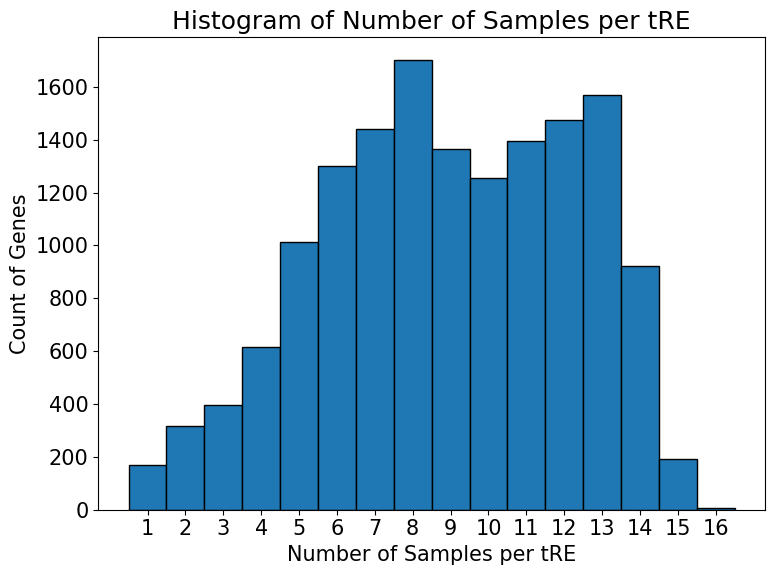

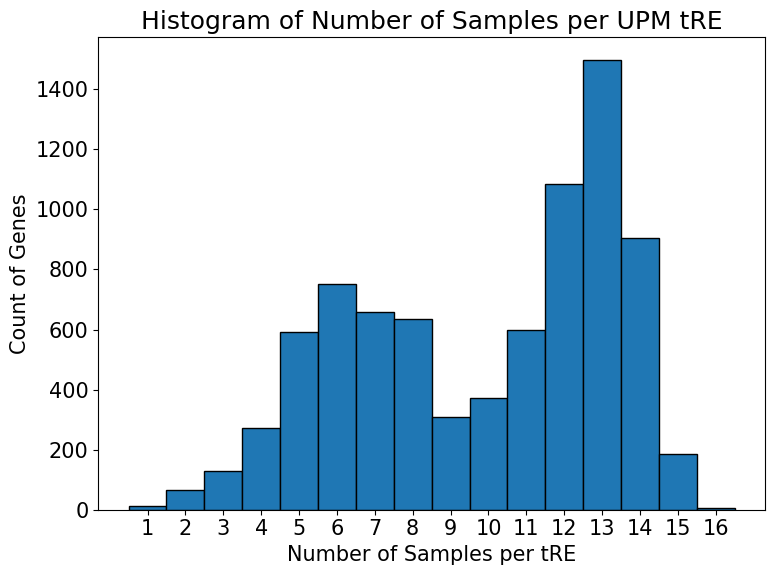

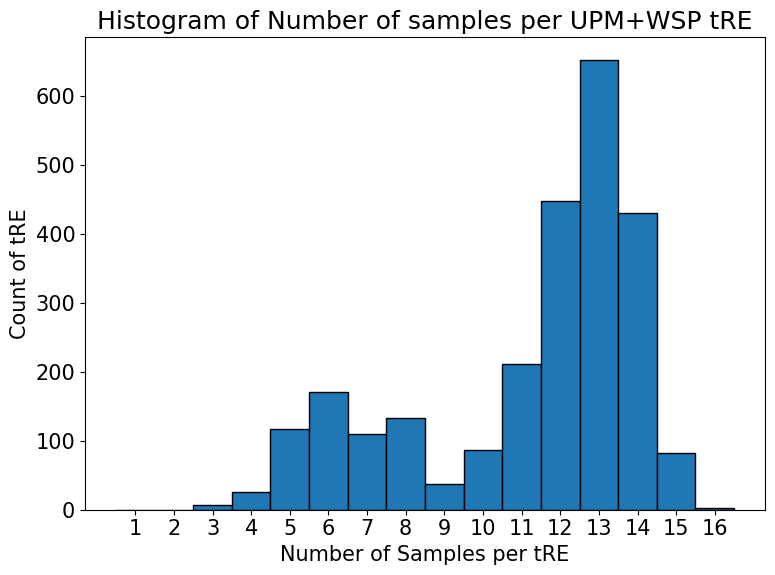

In [17]:
# Assuming your consensus DataFrame is called `consensus_df`
plt.figure(figsize=(8, 6))

# Compute histogram manually for discrete bins
counts, bins, patches = plt.hist(
    consensus['num_dataframes'], 
    bins=range(1, int(consensus['num_dataframes'].max()) + 2), 
    align='left', 
    edgecolor='black'
)

plt.xlabel('Number of Samples per tRE')
plt.ylabel('Count of Genes')
plt.xticks(range(1, int(consensus['num_dataframes'].max()) + 1))
plt.title('Histogram of Number of Samples per tRE')
plt.tight_layout()
plt.show()



# Assuming your consensus DataFrame is called `consensus_df`
plt.figure(figsize=(8, 6))

# Compute histogram manually for discrete bins
counts, bins, patches = plt.hist(
    consensus_upm['num_dataframes'], 
    bins=range(1, int(consensus_upm['num_dataframes'].max()) + 2), 
    align='left', 
    edgecolor='black'
)

plt.xlabel('Number of Samples per tRE')
plt.ylabel('Count of Genes')
plt.xticks(range(1, int(consensus_upm['num_dataframes'].max()) + 1))
plt.title('Histogram of Number of Samples per UPM tRE')
plt.tight_layout()
plt.show()

# Assuming your consensus DataFrame is called `consensus_df`
plt.figure(figsize=(8, 6))

# Compute histogram manually for discrete bins
counts, bins, patches = plt.hist(
    consensus_upmwsp['num_dataframes'], 
    bins=range(1, int(consensus_upmwsp['num_dataframes'].max()) + 2), 
    align='left', 
    edgecolor='black'
)

plt.xlabel('Number of Samples per tRE')
plt.ylabel('Count of tRE')
plt.xticks(range(1, int(consensus_upmwsp['num_dataframes'].max()) + 1))
plt.title('Histogram of Number of samples per UPM+WSP tRE')
plt.tight_layout()
plt.show()

## Get the final bedfiles of the calls

In [18]:
consensus.columns

Index(['gene', 'weighted_pos_end', 'weighted_neg_end', 'weighted_pos_start',
       'weighted_neg_start', 'std_pos_end', 'std_neg_end', 'std_pos_mL',
       'std_neg_mL_a', 'num_dataframes', 'avg_pos_cov_nob', 'avg_neg_cov_nob',
       'keysource_pos', 'keysource_neg'],
      dtype='object')

In [19]:
## 
def get_matched_stranded_bed(consensus_df):
    consensus_df = consensus_df.copy()
    # Split the 'gene' column by ":" into two new columns
    split = consensus_df['gene'].str.split(":", n=1, expand=True)
    consensus_df['chrom'] = split[0]
    consensus_df['mu'] = split[1].astype(int)
    
    # Stranded bed
    pos_bed = pd.DataFrame({"chr": consensus_df.chrom, 
                                   "start": consensus_df.mu + consensus_df.weighted_pos_start.fillna(0).astype(int), 
                            "end": consensus_df.mu + consensus_df.weighted_pos_end.fillna(100).astype(int), 
                                  "name": consensus_df["gene"]+"|+" , 
                                    "LIET_coverage": consensus_df.avg_pos_cov_nob.fillna(0).astype(int),
                                    "strand": ["+"]*consensus_df.shape[0],
                               "mu":consensus_df.mu, 
                           "gene": consensus_df["gene"]})
    neg_bed = pd.DataFrame({"chr": consensus_df.chrom, 
                                   "start": consensus_df.mu - consensus_df.weighted_neg_end.fillna(100).astype(int), 
                            "end": consensus_df.mu + consensus_df.weighted_neg_start.fillna(0).astype(int), 
                                  "name": consensus_df["gene"]+"|-" , 
                                    "LIET_coverage": consensus_df.avg_neg_cov_nob.fillna(0).astype(int),
                                    "strand": ["-"]*consensus_df.shape[0],
                               "mu":consensus_df.mu, 
                               "gene": consensus_df["gene"]})
    full_bed = pd.concat([pos_bed, neg_bed])
    full_bed['length'] = full_bed['end'] - full_bed['start']

    one_bed = pd.DataFrame({"chr": consensus_df.chrom, 
                                   "start": consensus_df.mu - consensus_df.weighted_neg_end.fillna(100).astype(int), 
                            "end": consensus_df.mu + consensus_df.weighted_pos_end.fillna(100).astype(int), 
                                  "name": consensus_df["gene"] , 
                                    "LIET_coverage": consensus_df.avg_pos_cov_nob.fillna(0).astype(int).astype(str) + "," + consensus_df.avg_neg_cov_nob.fillna(0).astype(int).astype(str),
                                    "strand": ["+"]*consensus_df.shape[0],
                               "mu":consensus_df.mu})
    one_bed['pos_length'] = one_bed['end'] - one_bed['mu']
    one_bed['neg_length'] = one_bed['mu'] - one_bed['start']
    return(full_bed, one_bed)

cons_full_bed, cons_one_bed = get_matched_stranded_bed(consensus)
upm_full_bed, upm_one_bed = get_matched_stranded_bed(consensus_upm)
upmwsp_full_bed, upmwsp_one_bed = get_matched_stranded_bed(consensus_upmwsp)

In [20]:
upmwsp_one_bed.iloc[1:3,]

,chr,start,end,name,LIET_coverage,strand,mu,pos_length,neg_length
12,chr10,101031644,101032949,chr10:101032487,"243,519",+,101032487,462,843
13,chr10,101067077,101068325,chr10:101067718,"120,520",+,101067718,607,641


## Evaluate if regions are found with poor paddings

In [21]:
cons_full_bed[cons_full_bed["name"] == "chr10:101001615|-"]

,chr,start,end,name,LIET_coverage,strand,mu,gene,length
11,chr10,100998808,101001675,chr10:101001615|-,120,-,101001615,chr10:101001615,2867


In [23]:
# Read in the file
pad_file = pd.read_csv(
    "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/LIET/LIET_input/Pad_file_05.14.25.txt",
    sep="\t",
    header=None
)
pad_file.columns = ["Gene", "full_pad"]
# Split the second column by comma into two new columns: 'neg' and 'pos'
split = pad_file.iloc[:, 1].str.split(",", expand=True)
pad_file['neg_pad'] = split[0].astype(int)
pad_file['pos_pad'] = split[1].astype(int)

## ONE
cons_pad_file = pad_file[pad_file['Gene'].isin(cons_one_bed['name'])]
upm_pad_file = pad_file[pad_file['Gene'].isin(upm_one_bed['name'])]
upmwsp_pad_file = pad_file[pad_file['Gene'].isin(upmwsp_one_bed['name'])]

cons_pad_file = cons_pad_file.sort_values('Gene').reset_index(drop=True)
upm_pad_file = upm_pad_file.sort_values('Gene').reset_index(drop=True)
upmwsp_pad_file = upmwsp_pad_file.sort_values('Gene').reset_index(drop=True)
cons_one_bed = cons_one_bed.sort_values('name').reset_index(drop=True)
upm_one_bed = upm_one_bed.sort_values('name').reset_index(drop=True)
upmwsp_one_bed = upmwsp_one_bed.sort_values('name').reset_index(drop=True)

# Check if names match
print((cons_one_bed['name'] == cons_pad_file['Gene']).all())  # Should print True
print((upm_one_bed['name'] == upm_pad_file['Gene']).all())  # Should print True
print((upmwsp_one_bed['name'] == upmwsp_pad_file['Gene']).all())  # Should print True

# Combine relevant columns
cons_one_bed_pad = pd.concat([cons_one_bed, cons_pad_file[['Gene', 'neg_pad', 'pos_pad']]], axis=1)
upm_one_bed_pad = pd.concat([upm_one_bed, upm_pad_file[['Gene', 'neg_pad', 'pos_pad']]], axis=1)
upmwsp_one_bed_pad = pd.concat([upmwsp_one_bed, upmwsp_pad_file[['Gene', 'neg_pad', 'pos_pad']]], axis=1)



### STRANDED
# Create the 'name' field with "|+" and "|-"
pad_file1 = pad_file.copy()
pad_file['name'] = pad_file.iloc[:, 0] + "|+"
pad_file["L_pad"] = pad_file['pos_pad']
pad_file1['name'] = pad_file1.iloc[:, 0] + "|-"
pad_file1["L_pad"] = pad_file1['neg_pad']

# Concatenate the two DataFrames
pad_file = pd.concat([pad_file, pad_file1], ignore_index=True)

# Keep only rows where 'name' is in full_bed['name']
cons_pad_file = pad_file[pad_file['name'].isin(cons_full_bed['name'])]
upm_pad_file = pad_file[pad_file['name'].isin(upm_full_bed['name'])]
upmwsp_pad_file = pad_file[pad_file['name'].isin(upmwsp_full_bed['name'])]


# Sort both DataFrames by name
cons_pad_file = cons_pad_file.sort_values('name').reset_index(drop=True)
upm_pad_file = upm_pad_file.sort_values('name').reset_index(drop=True)
upmwsp_pad_file = upmwsp_pad_file.sort_values('name').reset_index(drop=True)
cons_full_bed = cons_full_bed.sort_values('name').reset_index(drop=True)
upm_full_bed = upm_full_bed.sort_values('name').reset_index(drop=True)
upmwsp_full_bed = upmwsp_full_bed.sort_values('name').reset_index(drop=True)

# Check if names match
print((cons_full_bed['name'] == cons_pad_file['name']).all())  # Should print True
print((upm_full_bed['name'] == upm_pad_file['name']).all())  # Should print True
print((upmwsp_full_bed['name'] == upmwsp_pad_file['name']).all())  # Should print True

# Combine relevant columns
cons_full_bed_pad = pd.concat([cons_full_bed, cons_pad_file[['name', 'L_pad']]], axis=1)
upm_full_bed_pad = pd.concat([upm_full_bed, upm_pad_file[['name', 'L_pad']]], axis=1)
upmwsp_full_bed_pad = pd.concat([upmwsp_full_bed, upmwsp_pad_file[['name', 'L_pad']]], axis=1)


True
True
True
True
True
True


In [24]:
## How many calls are larger than the padding
cons_over_pad = cons_full_bed_pad[cons_full_bed_pad['length'] > cons_full_bed_pad['L_pad']]
upm_over_pad = upm_full_bed_pad[upm_full_bed_pad['length'] > upm_full_bed_pad['L_pad']]
upmwsp_over_pad = upmwsp_full_bed_pad[upmwsp_full_bed_pad['length'] > upmwsp_full_bed_pad['L_pad']]

print("Number of stranded transcripts with calls over the padding:", 
      cons_over_pad.shape[0], upm_over_pad.shape[0], upmwsp_over_pad.shape[0])
print("Number of enhancers with calls over the padding:", 
      len(set(cons_over_pad.gene)), len(set(upm_over_pad.gene)), len(set(upmwsp_over_pad.gene)))

Number of stranded transcripts with calls over the padding: 2965 1732 792
Number of enhancers with calls over the padding: 2945 1717 786


### Where are the tREs falling?
1. Do bedtools overlap of 100bp regions with Exons and Introns
2. Read in the bedtools closest of bidirectionals with TSS of genes



In [35]:
# Read in overlaps with introns and exons and TSS bids
full_regions=pd.read_csv("/Users/hoto7260/projects/Resp_Env/Comb_UPM_WSP_ADP/LIET/TRE_SIGADPWSPUPM_100bp.bed", 
                         sep="\t", header=None)
OVERLAPS="/Users/hoto7260/projects/Resp_Env/Comb_UPM_WSP_ADP/LIET/overlaps/"
introns = pd.read_csv("".join([OVERLAPS, "overlap_SIGADPWSPUPM_100bp_intron.bed"]), sep="\t", header=None)
exons = pd.read_csv("".join([OVERLAPS, "overlap_SIGADPWSPUPM_100bp_exon.bed"]), sep="\t", header=None)
gene_tss = pd.read_csv("".join([OVERLAPS, "overlap_SIGADPWSPUPM_100bp_TSS1kb.bed"]), sep="\t", header=None)
full_regions["mu"] = full_regions[1] + 50
introns["mu"] = introns[1] + 50
exons["mu"] = exons[1] + 50
gene_tss["mu"] = gene_tss[1] + 50
full_regions["gene"] = full_regions[0] + ":" + full_regions["mu"].astype(str)
introns["gene"] = introns[0] + ":" + introns["mu"].astype(str)
exons["gene"] = exons[0] + ":" + exons["mu"].astype(str)
gene_tss["gene"] = gene_tss[0] + ":" + gene_tss["mu"].astype(str)

introns.iloc[0:2,]



,0,1,2,3,4,5,6,7,8,9,10,11,mu,gene
0,chr3,185335984,185336084,chr3:185335757-185336311,"up_adp, up_upm30, down_upm120",chr3,185285643,185428496,MAP3K13:NM_001242314.2,.,+,100,185336034,chr3:185336034
1,chr3,185335984,185336084,chr3:185335757-185336311,"up_adp, up_upm30, down_upm120",chr3,185285643,185443444,MAP3K13:NM_001242317.2,.,+,100,185336034,chr3:185336034


In [42]:
# Get the calls for all in order of preference: Exon, GeneTSS, Intron 
# Ensure you are working with sets for set operations
exon_tres = set(exons["gene"].unique())
gene_tss_tres = set(gene_tss["gene"].unique()).difference(exon_tres)
intron_tres = set(introns["gene"].unique()).difference(gene_tss_tres, exon_tres)
other_tres = set(full_regions["gene"].unique()).difference(exon_tres.union(gene_tss_tres, intron_tres))

# Print counts
print("Number of tREs within an Exon:", len(exon_tres),  
      "\n\tGeneTSS:", len(gene_tss_tres), 
      "\n\tIntron:", len(intron_tres), 
      "\n\tIntergenic:", len(other_tres), 
     "\n\tTotal:", len(exon_tres)+len(gene_tss_tres)+len(intron_tres)+len(other_tres), len(full_regions["gene"].unique()))

Number of tREs within an Exon: 1106 
	GeneTSS: 725 
	Intron: 7135 
	Intergenic: 6230 
	Total: 15196 15196


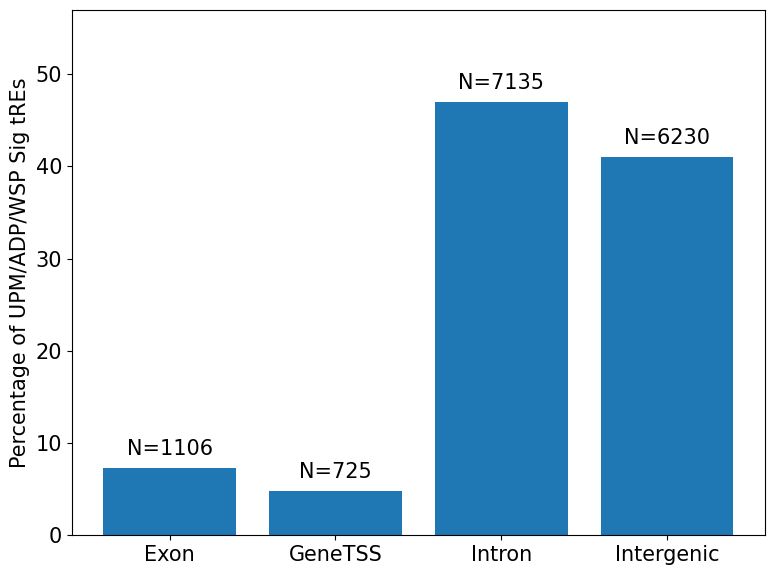

In [59]:
# Counts
counts = {
    "Exon": len(exon_tres),
    "GeneTSS": len(gene_tss_tres),
    "Intron": len(intron_tres),
    "Intergenic": len(other_tres)
}

# Calculate percentages
total = sum(counts.values())
percentages = {k: (v / total) * 100 for k, v in counts.items()}

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(percentages.keys(), percentages.values())

# Add text annotations above bars
for bar, label in zip(bars, counts.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"N={label}", ha='center', va='bottom', fontsize=15)

# Labeling
ax.set_ylabel("Percentage of UPM/ADP/WSP Sig tREs")
ax.set_ylim(0, max(percentages.values()) + 10)

plt.tight_layout()
plt.show()

#### Now when only considering those that are significant in both WSP & UPM

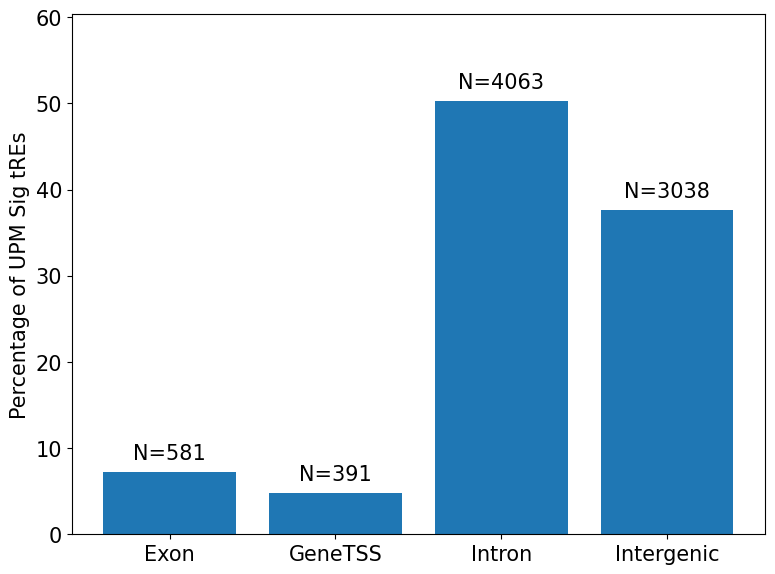

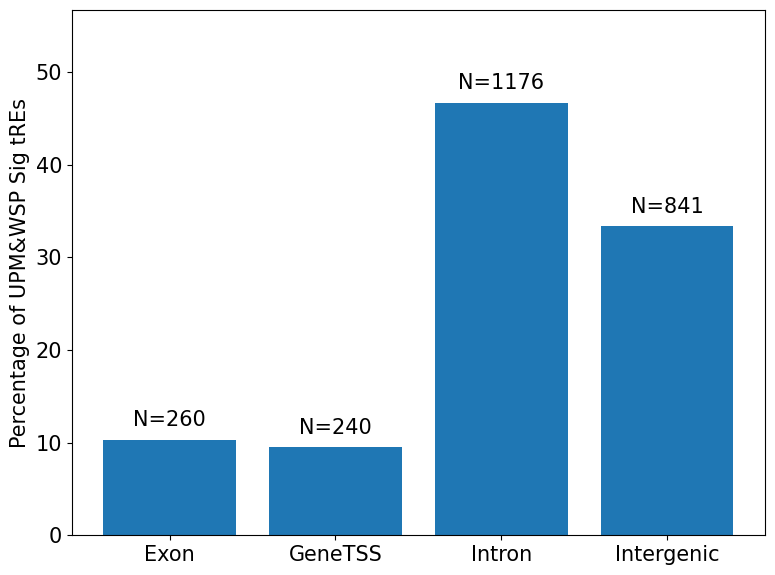

In [57]:
exon_tres_wspupm = exon_tres.intersection(upmwsp_sig["gene"].tolist())
gene_tss_tres_wspupm = gene_tss_tres.intersection(upmwsp_sig["gene"].tolist())
intron_tres_wspupm = intron_tres.intersection(upmwsp_sig["gene"].tolist())
other_tres_wspupm = other_tres.intersection(upmwsp_sig["gene"].tolist())

exon_tres_upm = exon_tres.intersection(upm_sig["gene"].tolist())
gene_tss_tres_upm = gene_tss_tres.intersection(upm_sig["gene"].tolist())
intron_tres_upm = intron_tres.intersection(upm_sig["gene"].tolist())
other_tres_upm = other_tres.intersection(upm_sig["gene"].tolist())

### UPM
# Counts
counts = {
    "Exon": len(exon_tres_upm),
    "GeneTSS": len(gene_tss_tres_upm),
    "Intron": len(intron_tres_upm),
    "Intergenic": len(other_tres_upm)
}
# Calculate percentages
total = sum(counts.values())
percentages = {k: (v / total) * 100 for k, v in counts.items()}
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(percentages.keys(), percentages.values())
# Add text annotations above bars
for bar, label in zip(bars, counts.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"N={label}", ha='center', va='bottom', fontsize=15)
# Labeling
ax.set_ylabel("Percentage of UPM Sig tREs")
ax.set_ylim(0, max(percentages.values()) + 10)

plt.tight_layout()
plt.show()

### UPM+WSP
# Counts
counts = {
    "Exon": len(exon_tres_wspupm),
    "GeneTSS": len(gene_tss_tres_wspupm),
    "Intron": len(intron_tres_wspupm),
    "Intergenic": len(other_tres_wspupm)
}
# Calculate percentages
total = sum(counts.values())
percentages = {k: (v / total) * 100 for k, v in counts.items()}
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(percentages.keys(), percentages.values())
# Add text annotations above bars
for bar, label in zip(bars, counts.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"N={label}", ha='center', va='bottom', fontsize=15)
# Labeling
ax.set_ylabel("Percentage of UPM&WSP Sig tREs")
ax.set_ylim(0, max(percentages.values()) + 10)

plt.tight_layout()
plt.show()



#### What is the identty of the underpadded calls?

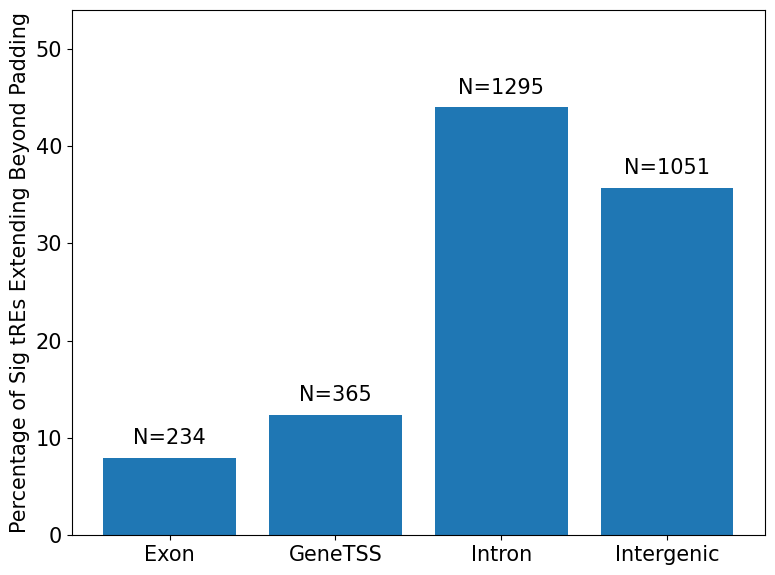

In [61]:
exon_tres_over = exon_tres.intersection(cons_over_pad["gene"].tolist())
gene_tss_tres_over = gene_tss_tres.intersection(cons_over_pad["gene"].tolist())
intron_tres_over = intron_tres.intersection(cons_over_pad["gene"].tolist())
other_tres_over = other_tres.intersection(cons_over_pad["gene"].tolist())

### UPM
# Counts
counts = {
    "Exon": len(exon_tres_over),
    "GeneTSS": len(gene_tss_tres_over),
    "Intron": len(intron_tres_over),
    "Intergenic": len(other_tres_over)
}
# Calculate percentages
total = sum(counts.values())
percentages = {k: (v / total) * 100 for k, v in counts.items()}
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(percentages.keys(), percentages.values())
# Add text annotations above bars
for bar, label in zip(bars, counts.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"N={label}", ha='center', va='bottom', fontsize=15)
# Labeling
ax.set_ylabel("Percentage of Sig tREs Extending Beyond Padding")
ax.set_ylim(0, max(percentages.values()) + 10)

plt.tight_layout()
plt.show()


## Save the final regions as split into overlapping Gene TSS and Not
I looked at the above results on IGV and saw that a lot of the "bleeding" regions bled into the TSS region of the gene and I'm honestly not sure if they are alternative start sites of the gene or not.
Therefore, I will 1) overlap the full LIET regions with the TSS 1kb to clarify if an RNA is extending into that area or not. 2) I will 





### Overlap the LIET based regions with TSS 1kb regions

In [62]:
# Save the full regions
cons_one_bed_pad["dot"] = "."

cons_one_bed_pad[["chr", "start", "end", "name", "dot", "dot", 
                         "LIET_coverage", "mu", "neg_pad", "pos_pad"]].to_csv("LIET_ADPUPMWSP_05.15.25.bed", 
                               sep="\t", header=None, index=None)

In [72]:
tss_liet_over = pd.read_csv("".join([OVERLAPS, "overlap_SIGADPWSPUPM_LIET_TSS1kb.bed"]), sep="\t", header=None)
tss_liet_over.iloc[0:2,]
tss_liet_over_tres = tss_liet_over[3].unique()
len(tss_liet_over_tres)

3392

### NOTE: If all of these 3,392 tREs are in fact alternative start sites, that means most tREs actually fall within intergenic regions rather than introns.

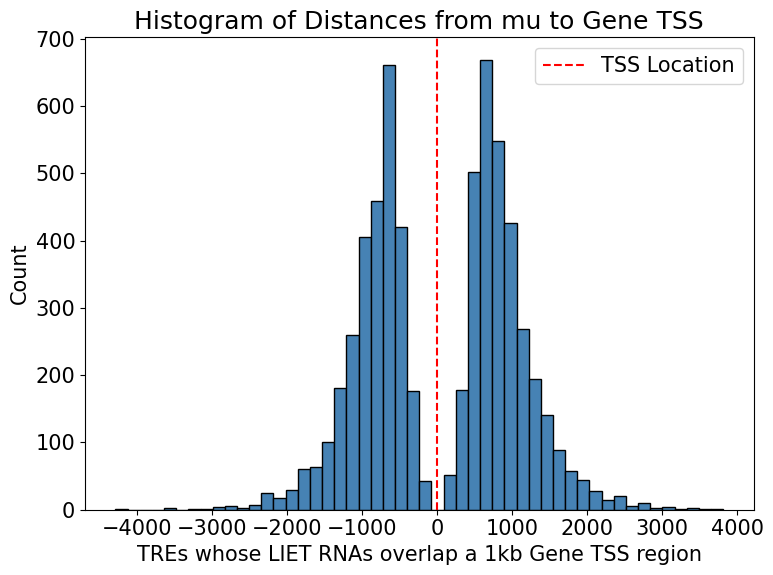

In [68]:

# plot the distance of the mus from the TSSs
tss_liet_over["TSS"] = tss_liet_over[11] + 500
tss_liet_over["TSS_Dist"] = tss_liet_over["TSS"] - tss_liet_over[7]


# Ensure distances are numeric and drop missing values
distances = pd.to_numeric(tss_liet_over["TSS_Dist"], errors="coerce").dropna()

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(distances, bins=50, color="steelblue", edgecolor="black")

# Labeling
plt.xlabel("TREs whose LIET RNAs overlap a 1kb Gene TSS region")
plt.ylabel("Count")
plt.title("Histogram of Distances from mu to Gene TSS")
plt.axvline(0, color='red', linestyle='--', label='TSS Location')
plt.legend()
plt.tight_layout()
plt.show()

Number of originally Exon TRES whose LIET RNAs overlap 1kb TSS region: 480


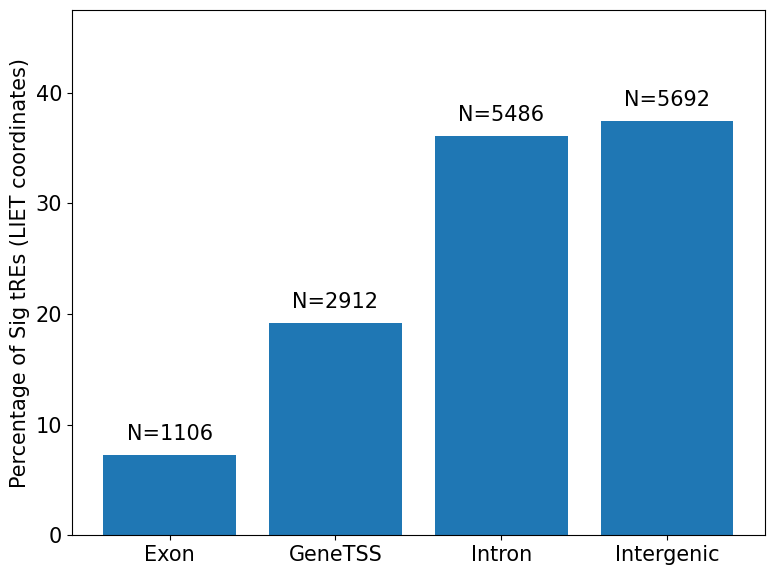

In [79]:
#### If we count these as gene tss calls now, where does that leave the comparisons
# keep exons the same
gene_tss_tres_LIET_exon = set(tss_liet_over_tres).intersection(exon_tres)
print("Number of originally Exon TRES whose LIET RNAs overlap 1kb TSS region:", len(gene_tss_tres_LIET_exon))
# don't include exon regions
gene_tss_tres_LIET = gene_tss_tres.union(set(tss_liet_over_tres).difference(gene_tss_tres_LIET_exon))
intron_tres_LIET = intron_tres.difference(gene_tss_tres_LIET.union(exon_tres))
other_tres_LIET = other_tres.difference(gene_tss_tres_LIET.union(intron_tres_LIET))

### UPM
# Counts
counts = {
    "Exon": len(exon_tres),
    "GeneTSS": len(gene_tss_tres_LIET),
    "Intron": len(intron_tres_LIET),
    "Intergenic": len(other_tres_LIET)
}
# Calculate percentages
total = sum(counts.values())
percentages = {k: (v / total) * 100 for k, v in counts.items()}
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(percentages.keys(), percentages.values())
# Add text annotations above bars
for bar, label in zip(bars, counts.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 1, f"N={label}", ha='center', va='bottom', fontsize=15)
# Labeling
ax.set_ylabel("Percentage of Sig tREs (LIET coordinates)")
ax.set_ylim(0, max(percentages.values()) + 10)

plt.tight_layout()
plt.show()


In [81]:
## Add the naming to the liet results bed
cons_one_bed_pad.iloc[1:2,]
cons_one_bed_pad["Feature"] = ""
cons_one_bed_pad.loc[cons_one_bed_pad["name"].isin(exon_tres), "Feature"] = "Exon"
cons_one_bed_pad.loc[cons_one_bed_pad["name"].isin(intron_tres), "Feature"] = "Intron"
cons_one_bed_pad.loc[cons_one_bed_pad["Feature"] == "", "Feature"] = "Intergenic"
# Overwrite with LIET-based annotation if applicable
is_liet = cons_one_bed_pad["name"].isin(tss_liet_over_tres)
cons_one_bed_pad.loc[is_liet & (cons_one_bed_pad["Feature"] == "Exon"), "Feature"] = "LIET Gene TSS Exon"
cons_one_bed_pad.loc[is_liet & (cons_one_bed_pad["Feature"] == "Intron"), "Feature"] = "LIET Gene TSS Intron"
cons_one_bed_pad.loc[is_liet & (cons_one_bed_pad["Feature"] == "Intergenic"), "Feature"] = "LIET Gene TSS Intergenic"


cons_one_bed_pad.iloc[0:3,]

,chr,start,end,name,LIET_coverage,strand,mu,pos_length,neg_length,Gene,neg_pad,pos_pad,dot,Feature
0,chr10,100006407,100007784,chr10:100006622,"170,1",+,100006622,1162,215,chr10:100006622,3000,3000,.,Intron
1,chr10,100191336,100192138,chr10:100191659,"25,5",+,100191659,479,323,chr10:100191659,3000,3000,.,Intron
2,chr10,100311193,100312111,chr10:100311438,"17,6",+,100311438,673,245,chr10:100311438,3000,300,.,Intron


In [82]:
cons_one_bed_pad["Feature"].value_counts().reset_index(name="Count").rename(columns={"index": "Feature"})

,Feature,Count
0,Intergenic,5657
1,Intron,5462
2,LIET Gene TSS Intron,1649
3,LIET Gene TSS Intergenic,1263
4,Exon,625
5,LIET Gene TSS Exon,480


In [83]:
5657+5462+1649+1263+625+480

15136

In [84]:
# save file
cons_one_bed_pad[["chr", "start", "end", "name", "dot", "dot", 
                         "LIET_coverage", "mu", "neg_pad", "pos_pad", "Feature"]].to_csv("LIET_ADPUPMWSP_05.15.25.bed", 
                               sep="\t", header=None, index=None)

## Get calls as final SNP focused analyses
1. Read in the Gene TSS 100bp regions of genes called significant in any of the methods
2. Read in the 100bp TREs that weren't captured by LIET
3. Add them to the LIET pad file, clarifying the Feature

In [91]:
# gene TSS 100bp regions
gene_tss_100bp = pd.read_csv("GeneTSS_ADPWSPUPM_100bp.sorted.bed", 
                            header=None, sep="\t")
# gene TRE 100bp regions not called
cons_sig_noLIET = cons_sig[~cons_sig["gene"].isin(cons_one_bed_pad["name"])]
print(cons_sig_noLIET.shape)
cons_sig_noLIET.iloc[0:3,]

(60, 7)


,0,1,2,3,4,mu,gene
428,chr7,80584014,80584114,chr7:80583776-80584352,down_adp,80584064,chr7:80584064
516,chr2,180461907,180462007,chr2:180461706-180462208,down_adp,180461957,chr2:180461957
8571,chr15,68384998,68385098,chr15:68384885-68385211,"up_wsp30, down_wsp120",68385048,chr15:68385048


In [102]:
gene_tss_100bp.iloc[0:2,]
gene_tss_100bp["mu"] = gene_tss_100bp[1] + 50
gene_tss_100bp["gene"] = gene_tss_100bp[0] + gene_tss_100bp["mu"].astype(str)

In [108]:
cons_one_bed_full = cons_one_bed_pad[["chr", "start", "end", "name", 
                                     "Feature"]]
print(cons_one_bed_full.shape)

(15136, 5)


In [109]:
cons_sig_noLIET_df = pd.DataFrame({"chr":cons_sig_noLIET[0], 
            "start":cons_sig_noLIET[1], "end":cons_sig_noLIET[2], 
            "name":cons_sig_noLIET["gene"], "Feature":"noLIET"})
cons_sig_noLIET_df.iloc[0:2,]
print(cons_sig_noLIET_df.shape)

gene_tss_100bp_df = pd.DataFrame({"chr":gene_tss_100bp[0], 
            "start":gene_tss_100bp[1], "end":gene_tss_100bp[2], 
            "name":gene_tss_100bp["gene"], "Feature":"Gene TSS Bid"})
print(gene_tss_100bp_df.shape)

(60, 5)
(15680, 5)


In [110]:
cons_one_bed_full = pd.concat([cons_one_bed_full, 
                               cons_sig_noLIET_df, 
                               gene_tss_100bp_df])
print(cons_one_bed_full.shape, 
     15136+60+15680)
cons_one_bed_full.iloc[0:2,]

(30876, 5) 30876


,chr,start,end,name,Feature
0,chr10,100006407,100007784,chr10:100006622,Intron
1,chr10,100191336,100192138,chr10:100191659,Intron


In [111]:
# save the file
cons_one_bed_full.to_csv("Full_withLIET_ADPUPMWSP_GeneTRE_05.15.25.bed", 
                               sep="\t", header=None, index=None)

In [93]:
cons_one_bed_pad.columns

Index(['chr', 'start', 'end', 'name', 'LIET_coverage', 'strand', 'mu',
       'pos_length', 'neg_length', 'Gene', 'neg_pad', 'pos_pad', 'dot',
       'Feature'],
      dtype='object')

In [ ]:
bedtools sort -i Full_withLIET_ADPUPMWSP_GeneTRE_05.15.25.bed > Full_withLIET_ADPUPMWSP_GeneTRE_05.15.25.sorted.bed

bedtools merge -c 4,5 -o "collapse" -delim ";" -i Full_withLIET_ADPUPMWSP_GeneTRE_05.15.25.sorted.bed >  Full_withLIET_ADPUPMWSP_GeneTRE_05.15.25.merged.bed



### How many of these are due to me extending padding to 500 when I shouldn't have?

In [258]:
# how many of these enhancers are due to me overextending paddings to 500 when I shouldn't have

og_pads = pd.read_csv('/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/LIET/LIET_input/Pad_file_05.15.25.txt', 
            sep="\t", header=None)
split = og_pads[1].str.split(", ", expand=True)
og_pads["Left"] = split[0]
og_pads["Right"] = split[1]
og_pads["Left_Name"] = og_pads[0] + "|-"
og_pads["Right_Name"] = og_pads[0] + "|+"
og_pads.iloc[0:10,]



,0,1,Left,Right,Left_Name,Right_Name
0,chr1:629925,"659, 1436",659,1436,chr1:629925|-,chr1:629925|+
1,chr1:631361,"1436, 1065",1436,1065,chr1:631361|-,chr1:631361|+
2,chr1:632426,"1065, 258",1065,258,chr1:632426|-,chr1:632426|+
3,chr1:634026,"1342, 3000",1342,3000,chr1:634026|-,chr1:634026|+
4,chr1:784855,"3000, 974",3000,974,chr1:784855|-,chr1:784855|+
5,chr1:785829,"974, 3000",974,3000,chr1:785829|-,chr1:785829|+
6,chr1:794406,"2800, 2962",2800,2962,chr1:794406|-,chr1:794406|+
7,chr1:797368,"2962, 3000",2962,3000,chr1:797368|-,chr1:797368|+
8,chr1:802446,"3000, 2307",3000,2307,chr1:802446|-,chr1:802446|+
9,chr1:804753,"2307, 792",2307,792,chr1:804753|-,chr1:804753|+


In [259]:
under300_right = og_pads[og_pads["Right"].astype(int) < 300]["Right_Name"].tolist()
under300_left = og_pads[og_pads["Left"].astype(int) < 300]["Left_Name"].tolist()
under300 = under300_right + under300_left
print("Number of transcripts under 300 pad:", len(under300))

cons_not_under300 = ~cons_over_pad['name'].isin(under300)
upm_not_under300 = ~upm_over_pad['name'].isin(under300)
upmwsp_not_under300 = ~upmwsp_over_pad['name'].isin(under300)

print("Number of stranded transcripts with calls over the padding:", 
      cons_over_pad.shape[0], upm_over_pad.shape[0], upmwsp_over_pad.shape[0])

print("Number of stranded transcripts with calls over the padding AND under 300:", 
      int(cons_not_under300.sum()[0]), int(upm_not_under300.sum()[0]), 
      int(upmwsp_not_under300.sum()[0]))

Number of transcripts under 300 pad: 886
Number of stranded transcripts with calls over the padding: 2965 1732 792
Number of stranded transcripts with calls over the padding AND under 300: 2531 1388 594


/tmp/ipykernel_122375/2040156431.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_122375/2040156431.py:15: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



### Save the bed files for the calls that do not have clear overextensions or issues

In [260]:
# First just check that
clean_upmwsp_one_bed_pad = upmwsp_one_bed_pad[(upmwsp_one_bed_pad['pos_length'] < upmwsp_one_bed_pad['pos_pad']) &
                                                (upmwsp_one_bed_pad['neg_length'] < upmwsp_one_bed_pad['neg_pad'])]
#print(clean_upmwsp_one_bed_pad.shape)

clean_upmwsp_one_bed_pad["dot"] = "."
clean_upmwsp_one_bed_pad.iloc[0:2,]
clean_upmwsp_one_bed_pad[["chr", "start", "end", "name", "dot", "dot", 
                         "LIET_coverage", "mu", "neg_pad", "pos_pad"]].to_csv("Clean_LIET_UPMWSP_05.15.25.bed", 
                               sep="\t", header=None, index=None)

upmwsp_full_bed_pad["dot"] = "."
upmwsp_full_bed_pad[["chr", "start", "end", "name", "dot", "strand", 
                         "LIET_coverage", "mu", "L_pad"]].to_csv("Full_LIET_UPMWSP_05.15.25.bed", 
                               sep="\t", header=None, index=None)

/tmp/ipykernel_122375/2078399672.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [262]:
# First just check that
clean_cons_one_bed_pad = cons_one_bed_pad[(cons_one_bed_pad['pos_length'] < cons_one_bed_pad['pos_pad']) &
                                                (cons_one_bed_pad['neg_length'] < cons_one_bed_pad['neg_pad'])]
#print(clean_upmwsp_one_bed_pad.shape)

clean_cons_one_bed_pad["dot"] = "."
clean_cons_one_bed_pad.iloc[0:2,]
clean_cons_one_bed_pad[["chr", "start", "end", "name", "dot", "dot", 
                         "LIET_coverage", "mu", "neg_pad", "pos_pad"]].to_csv("Clean_LIET_ADPUPMWSP_05.15.25.bed", 
                               sep="\t", header=None, index=None)

cons_full_bed_pad["dot"] = "."
cons_full_bed_pad[["chr", "start", "end", "name", "dot", "strand", 
                         "LIET_coverage", "mu", "L_pad"]].to_csv("Full_LIET_ADPUPMWSP_05.15.25.bed", 
                               sep="\t", header=None, index=None)

/tmp/ipykernel_122375/851246301.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [261]:
clean_upmwsp_full_bed_pad = upmwsp_full_bed_pad[upmwsp_full_bed_pad['length'] < upmwsp_full_bed_pad['L_pad']]
print(upmwsp_full_bed_pad.shape, clean_upmwsp_full_bed_pad.shape)

clean_upm_full_bed_pad = upm_full_bed_pad[upm_full_bed_pad['length'] < upm_full_bed_pad['L_pad']]
print(upm_full_bed_pad.shape, clean_upm_full_bed_pad.shape)

clean_cons_full_bed_pad = cons_full_bed_pad[cons_full_bed_pad['length'] < cons_full_bed_pad['L_pad']]
print(cons_full_bed_pad.shape, clean_cons_full_bed_pad.shape)

(5034, 12) (4240, 12)
(16146, 11) (14408, 11)
(30272, 11) (27297, 11)


In [194]:
clean_cons_full_bed_pad.iloc[1:3,]

,chr,start,end,name,LIET_coverage,strand,mu,gene,length,name,L_pad
1,chr10,100006522,100006622,chr10:100006622|-,0,-,100006622,chr10:100006622,100,chr10:100006622|-,3000
2,chr10,100191667,100192157,chr10:100191659|+,46,+,100191659,chr10:100191659,490,chr10:100191659|+,3000
